In [1]:
%load_ext autoreload
%autoreload 2

## 00 - Data Audit

This notebook reviews the raw credit default dataset before modeling.

The goal is to identify data quality issues, undocumented categories, class imbalance, duplicated rows, missing, values and cleaning decisions that will be applied later in the modeling pipeline.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from credit_default.data import load_credit_data

import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

In [3]:
def revisar_log(df, columnas):
  resumen = []

  for col in columnas:
      total = len(df)
      zeros = (df[col] == 0).sum()
      negatives = (df[col] < 0).sum()
      positives = (df[col] > 0).sum()
      missing = df[col].isna().sum()

      resumen.append({
          "columna": col,
          "total": total,
          "zeros": zeros,
          "zeros_pct": zeros / total,
          "negatives": negatives,
          "negatives_pct": negatives / total,
          "positives": positives,
          "missing": missing,
          "puede_log": negatives == 0 and zeros == 0,
          "puede_log1p": negatives == 0
      })

  return pd.DataFrame(resumen)


In [4]:
data = load_credit_data()

In [8]:
data.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [25]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [26]:
target = 'default payment next month'

payment_cols = [f'PAY_{i}' for i in range(0, 7)]
payment_cols.remove('PAY_1') ## Doest not exist in docs

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE'] + payment_cols

bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]

pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

numeric_cols = bill_cols + pay_cols

In [27]:
for columna in cat_cols:
  print(f'Nombre de Columna: {columna}')
  print(data[columna].unique())

Nombre de Columna: SEX
[2 1]
Nombre de Columna: EDUCATION
[2 1 3 5 4 6 0]
Nombre de Columna: MARRIAGE
[1 2 3 0]
Nombre de Columna: PAY_0
[ 2 -1  0 -2  1  3  4  8  7  5  6]
Nombre de Columna: PAY_2
[ 2  0 -1 -2  3  5  7  4  1  6  8]
Nombre de Columna: PAY_3
[-1  0  2 -2  3  4  6  7  1  5  8]
Nombre de Columna: PAY_4
[-1  0 -2  2  3  4  5  7  6  1  8]
Nombre de Columna: PAY_5
[-2  0 -1  2  3  5  4  7  8  6]
Nombre de Columna: PAY_6
[-2  2  0 -1  3  6  4  7  8  5]


In [10]:
## These are columns with extra labels, they dont appear in docs
## -2  is not a documented label, this appears on PAY_*

cols_sospechosas = ['EDUCATION', 'MARRIAGE']

print('Columnas con Zeros en Education y Marriage')

for columna in cols_sospechosas:
  view_zeroes = data[data[columna] == 0]
  print(view_zeroes.shape)

Columnas con Zeros en Education y Marriage
(14, 25)
(54, 25)


## Respecto a Education y Marriage

Se han detectado categorias no documentadas como 0, para este ejercicio los registros con cero en education seran removidos, mientras que marriage, se mandara a la categoria 'others.

In [11]:
cols_sospechosas = payment_cols

print('Columnas con Zeros en PAY_')

for columna in cols_sospechosas:
  print(f'Columna: {columna}')
  view_zeroes = data[data[columna] == -2]
  print(view_zeroes.shape)

Columnas con Zeros en PAY_
Columna: PAY_0
(2759, 25)
Columna: PAY_2
(3782, 25)
Columna: PAY_3
(4085, 25)
Columna: PAY_4
(4348, 25)
Columna: PAY_5
(4546, 25)
Columna: PAY_6
(4895, 25)


## Respecto a PAY_*

La categoría -2 no esta listada dentro de la documentación, sin embargo, al ser un conjunto de tamaño considerable, optaré por mantenerlo.

In [12]:
data['AGE'].unique()

array([24, 26, 34, 37, 57, 29, 23, 28, 35, 51, 41, 30, 49, 39, 40, 27, 47,
       33, 32, 54, 58, 22, 25, 31, 46, 42, 43, 45, 56, 44, 53, 38, 63, 36,
       52, 48, 55, 60, 50, 75, 61, 73, 59, 21, 67, 66, 62, 70, 72, 64, 65,
       71, 69, 68, 79, 74])

## Checking the clas imbalance

In [ ]:
data[target].isna().sum() ## No hay datos nulos

np.int64(0)

In [39]:
clase_1_len = data[target].sum() ## Suma de la clase 1
clase_0_len = data[data[target] == 0].shape[0]
total = len(data[target])

print(f'La clase 1 tiene {clase_1_len / total * 100:2f}% registros')
print(f'La clase 0 tiene {clase_0_len / total * 100:2f}% registros')

La clase 1 tiene 22.120000% registros
La clase 0 tiene 77.880000% registros


Data 0, columna: BILL_AMT1
Valor mínimo -165580, Valor máximo 964511
Data 1, columna: BILL_AMT2
Valor mínimo -69777, Valor máximo 983931
Data 2, columna: BILL_AMT3
Valor mínimo -157264, Valor máximo 1664089
Data 3, columna: BILL_AMT4
Valor mínimo -170000, Valor máximo 891586
Data 4, columna: BILL_AMT5
Valor mínimo -81334, Valor máximo 927171
Data 5, columna: BILL_AMT6
Valor mínimo -339603, Valor máximo 961664


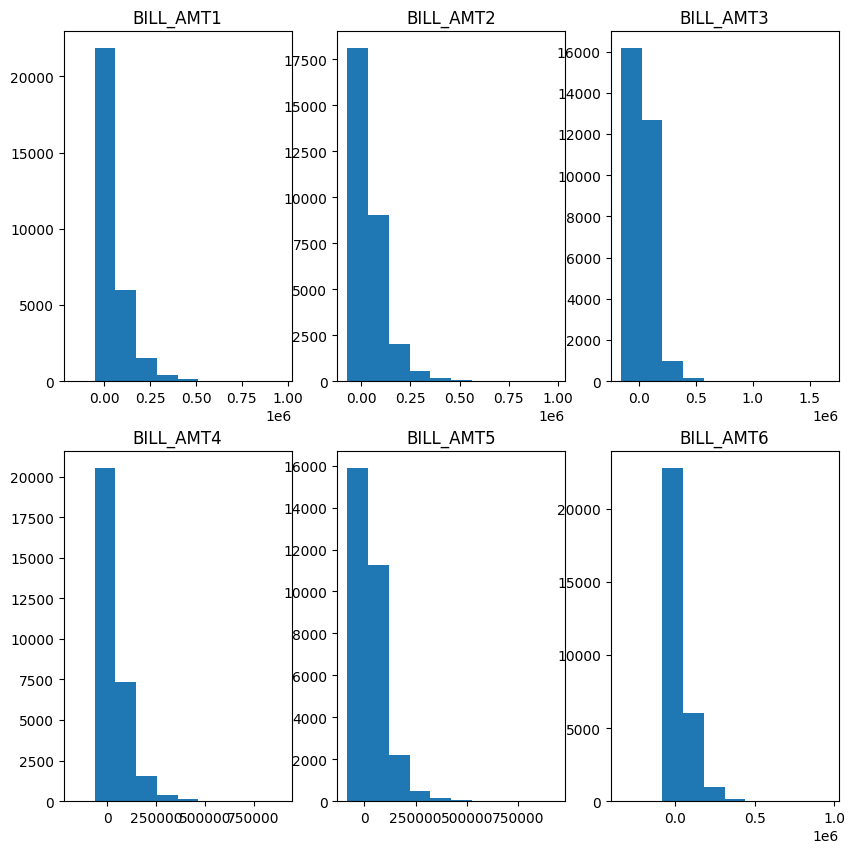

In [ ]:
plot_cols = 3
plot_rows = ceil(len(bill_cols) / plot_cols)

fig, axes = plt.subplots(plot_rows, plot_cols, figsize = (10, 10))

axes = axes.flatten()

for i, col in enumerate(bill_cols):
  print(f'Data {i}, columna: {col}')
  col_min = data[col].min()
  col_max = data[col].max()
  print(f'Valor mínimo {col_min}, Valor máximo {col_max}')
  axes[i].hist(data[col])
  axes[i].set_title(col)

plt.show()

## Nota

For `BILL_AMT*` columns, `np.log1p` should not be applied directly because some values are negative. Zeros are not a problem for `log1p`, but negative values require additional treatment.

In [30]:
resumen_log = revisar_log(data, bill_cols)
resumen_log

,columna,total,zeros,zeros_pct,negatives,negatives_pct,positives,missing,puede_log,puede_log1p
0,BILL_AMT1,30000,2008,0.066933,590,0.019667,27402,0,False,False
1,BILL_AMT2,30000,2506,0.083533,669,0.022300,26825,0,False,False
2,BILL_AMT3,30000,2870,0.095667,655,0.021833,26475,0,False,False
3,BILL_AMT4,30000,3195,0.106500,675,0.022500,26130,0,False,False
4,BILL_AMT5,30000,3506,0.116867,655,0.021833,25839,0,False,False
5,BILL_AMT6,30000,4020,0.134000,688,0.022933,25292,0,False,False


Data 0, columna: PAY_AMT1
Data 1, columna: PAY_AMT2
Data 2, columna: PAY_AMT3
Data 3, columna: PAY_AMT4
Data 4, columna: PAY_AMT5
Data 5, columna: PAY_AMT6


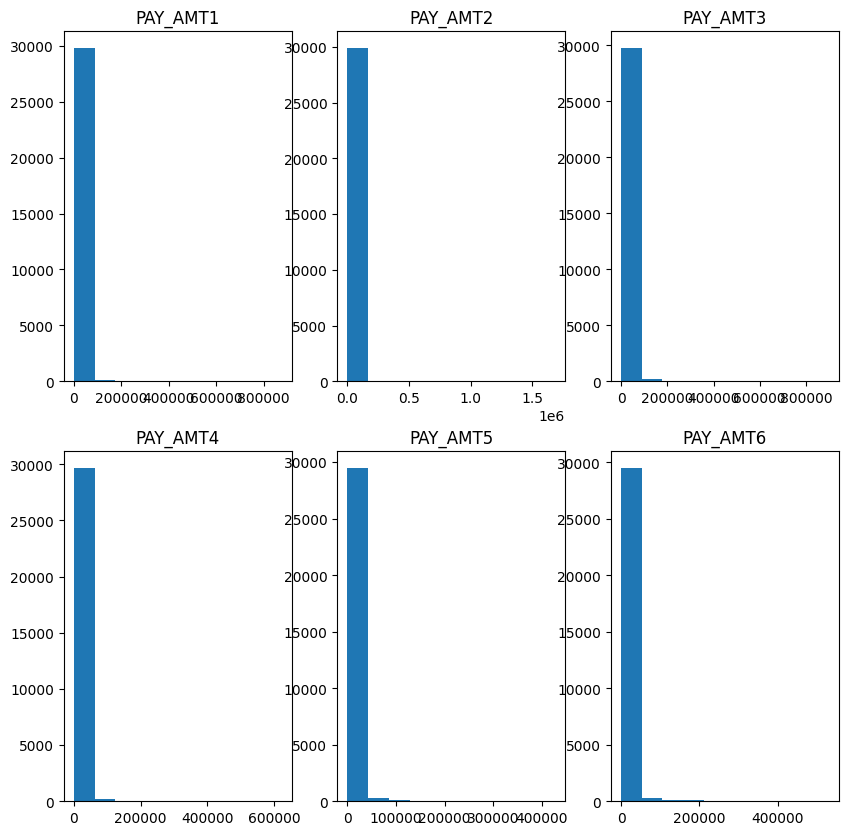

In [31]:
plot_cols = 3
plot_rows = ceil(len(pay_cols) / plot_cols)

fig, axes = plt.subplots(plot_rows, plot_cols, figsize = (10, 10))

axes = axes.flatten()

for i, col in enumerate(pay_cols):
  print(f'Data {i}, columna: {col}')
  axes[i].hist(data[col])
  axes[i].set_title(col)

plt.show()

In [32]:
resumen_log_payment = revisar_log(data, pay_cols)
resumen_log_payment

,columna,total,zeros,zeros_pct,negatives,negatives_pct,positives,missing,puede_log,puede_log1p
0,PAY_AMT1,30000,5249,0.174967,0,0.0,24751,0,False,True
1,PAY_AMT2,30000,5396,0.179867,0,0.0,24604,0,False,True
2,PAY_AMT3,30000,5968,0.198933,0,0.0,24032,0,False,True
3,PAY_AMT4,30000,6408,0.213600,0,0.0,23592,0,False,True
4,PAY_AMT5,30000,6703,0.223433,0,0.0,23297,0,False,True
5,PAY_AMT6,30000,7173,0.239100,0,0.0,22827,0,False,True


## Nota

Ocurre un fenomeno similar a BillAmount, sin embargo este es candidato a una transformación np.log1p durante el preprocessing pipeline.

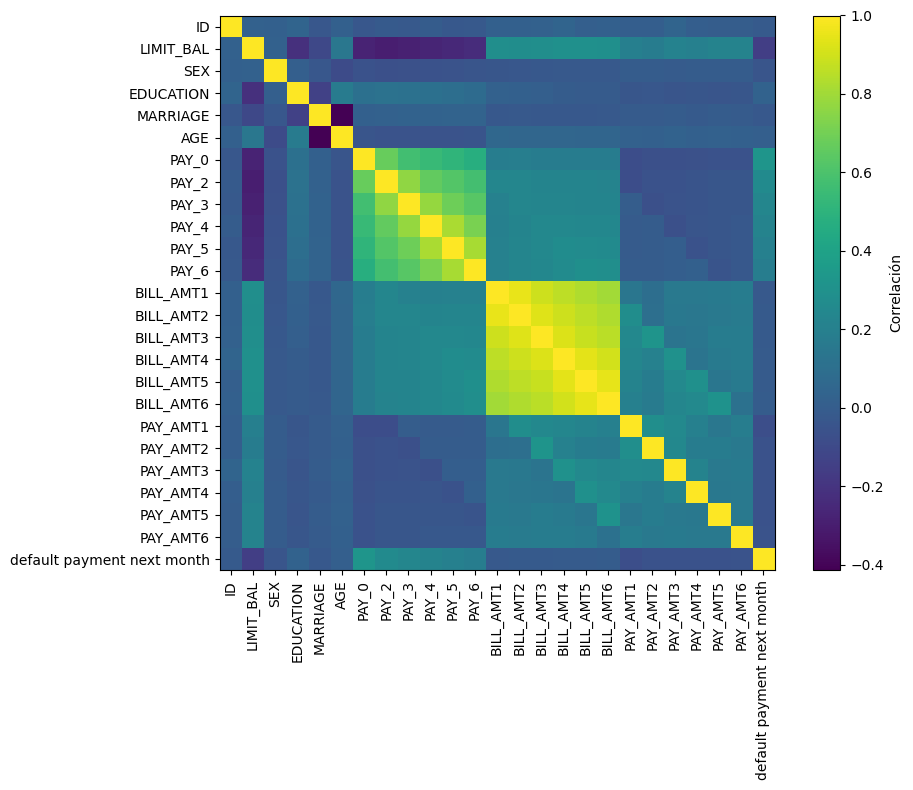

In [36]:
## Solo un check rápido de corr visual, más adelante valoro a profundidad.
plt.close('all')
plt.rcdefaults()

corr = data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap='viridis')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

fig.colorbar(im, ax=ax, label='Correlación')

plt.tight_layout()
plt.show()

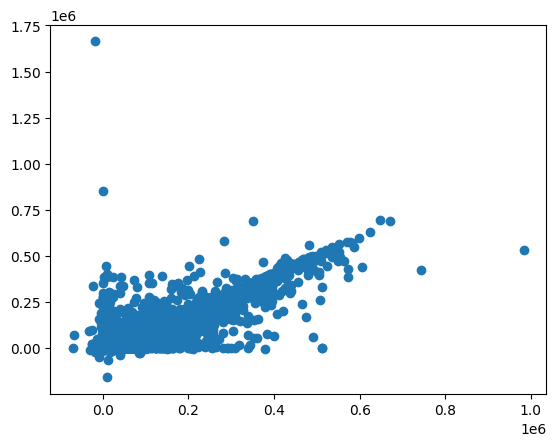

In [37]:
x = data['BILL_AMT2']
y = data['BILL_AMT3']

plt.scatter(
    x,y
)

In [38]:
data.skew()

ID                             0.000000
LIMIT_BAL                      0.992867
SEX                           -0.424183
EDUCATION                      0.970972
MARRIAGE                      -0.018742
AGE                            0.732246
PAY_0                          0.731975
PAY_2                          0.790565
PAY_3                          0.840682
PAY_4                          0.999629
PAY_5                          1.008197
PAY_6                          0.948029
BILL_AMT1                      2.663861
BILL_AMT2                      2.705221
BILL_AMT3                      3.087830
BILL_AMT4                      2.821965
BILL_AMT5                      2.876380
BILL_AMT6                      2.846645
PAY_AMT1                      14.668364
PAY_AMT2                      30.453817
PAY_AMT3                      17.216635
PAY_AMT4                      12.904985
PAY_AMT5                      11.127417
PAY_AMT6                      10.640727
default payment next month     1.343504


## Resumen

- PAY_AMT amounts pueden ser transformadas por np.log1p y conviene dado su extremo skew
- Existen etiquetas no documentadas en Education y Marriage
- Education 0 sera removido
- Marriage tiene el valor cero (0) lo mandaremos a othr
- PAY_* tiene una categoria -2. lo mantendremos
- ID será removido.
- Target desbalanceado, cuidar no solo usar accuracy